<a href="https://colab.research.google.com/github/codeyson/cbp-crack-detection/blob/main/crack_pretrain_unet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crack segmentation pretraining (U-Net + pretrained encoder)
Dataset: DeepCrack (Kaggle: `rukiyeaydn/deepcrack-dataset`). **Runtime → Change runtime type → T4 GPU** before running.

Scores here only show the pipeline works. Report results from your own paver blocks (split by block ID), not from this dataset.

In [16]:
!pip -q install segmentation-models-pytorch albumentations

## 1. Download the dataset from Kaggle
Upload your `kaggle.json` when prompted (Kaggle → Settings → API → Create New Token).

In [17]:
import os
from google.colab import userdata, drive

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")
!pip -q install -U kaggle
!kaggle datasets download -d rukiyeaydn/deepcrack-dataset -p /content/data --unzip
drive.mount('/content/drive')  # checkpoints are saved here because Colab disconnects

Dataset URL: https://www.kaggle.com/datasets/rukiyeaydn/deepcrack-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 64.7M/64.7M [00:01<00:00, 65.2MB/s]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Config

In [31]:
import os, glob, random, json, numpy as np, cv2, torch, matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader

BACKBONE = "efficientnet-b0"      # "resnet50" | "mobilenet_v2" | "efficientnet-b0"
CROP     = 256             # training tile size
BATCH    = 16
EPOCHS   = 15 #30 initially
LR       = 3e-4
REPEAT   = 4               # random crops per image per epoch (dataset is small)
SEED     = 42
DATA     = "/content/data"
SAVE_DIR = "/content/drive/MyDrive/TIP Files/41S2/CPE 029 (PD1)/PD1 FILES (1)/Software"
os.makedirs(SAVE_DIR, exist_ok=True)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
use_amp = device == "cuda"
print("device:", device)

device: cuda


## 3. Data loading and preprocessing

train 255 | val 45 | test 237
batch: torch.Size([16, 3, 256, 256]) torch.Size([16, 1, 256, 256]) | crack pixel fraction: 0.057


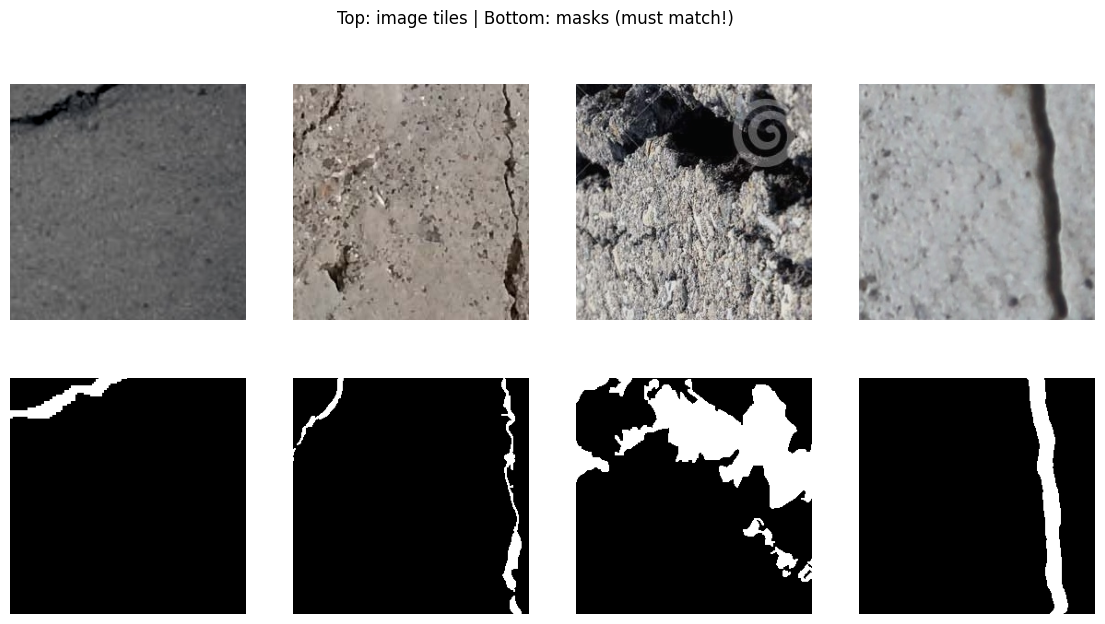

In [19]:
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)  # ImageNet stats, required by the pretrained encoders

def find_dir(name):
    hits = [p for p in glob.glob(f"{DATA}/**/{name}", recursive=True) if os.path.isdir(p)]
    assert hits, f"Folder '{name}' not found under {DATA}. Run: !find /content/data -maxdepth 3"
    return hits[0]

def get_pairs(img_dir, lab_dir):
    imgs = sorted(os.listdir(img_dir)); labs = sorted(os.listdir(lab_dir))
    lab_by_stem = {os.path.splitext(f)[0]: f for f in labs}
    pairs = [(f"{img_dir}/{f}", f"{lab_dir}/{lab_by_stem[os.path.splitext(f)[0]]}")
             for f in imgs if os.path.splitext(f)[0] in lab_by_stem]
    if len(pairs) != len(imgs):  # filenames don't match: fall back to sorted order
        assert len(imgs) == len(labs), "Image/mask counts differ, check the folders"
        print("WARNING: names did not match, pairing by sorted order. Verify with the plot below.")
        pairs = [(f"{img_dir}/{i}", f"{lab_dir}/{l}") for i, l in zip(imgs, labs)]
    return pairs

train_all = get_pairs(find_dir("train_img"), find_dir("train_lab"))
test_pairs = get_pairs(find_dir("test_img"), find_dir("test_lab"))

random.shuffle(train_all)
n_val = int(0.15 * len(train_all))
val_pairs, train_pairs = train_all[:n_val], train_all[n_val:]
print(f"train {len(train_pairs)} | val {len(val_pairs)} | test {len(test_pairs)}")

train_tf = A.Compose([
    A.PadIfNeeded(min_height=CROP, min_width=CROP),
    A.RandomCrop(CROP, CROP),
    A.HorizontalFlip(), A.VerticalFlip(), A.RandomRotate90(),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(mean=MEAN, std=STD), ToTensorV2(),
])
eval_tf = A.Compose([A.Normalize(mean=MEAN, std=STD), ToTensorV2()])

class CrackDS(Dataset):
    def __init__(self, pairs, tf, train):
        self.pairs, self.tf, self.train = pairs, tf, train
    def __len__(self):
        return len(self.pairs) * (REPEAT if self.train else 1)
    def __getitem__(self, i):
        ip, mp = self.pairs[i % len(self.pairs)]
        img = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
        mask = (cv2.imread(mp, cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
        if not self.train:  # pad to a multiple of 32 (U-Net requirement); batch size 1 for eval
            h, w = mask.shape
            ph, pw = (-h) % 32, (-w) % 32
            img = np.pad(img, ((0, ph), (0, pw), (0, 0))); mask = np.pad(mask, ((0, ph), (0, pw)))
        out = self.tf(image=img, mask=mask)
        return out["image"], out["mask"].float().unsqueeze(0)

train_dl = DataLoader(CrackDS(train_pairs, train_tf, True), batch_size=BATCH, shuffle=True, num_workers=2, drop_last=True)
val_dl   = DataLoader(CrackDS(val_pairs, eval_tf, False), batch_size=1, num_workers=2)
test_dl  = DataLoader(CrackDS(test_pairs, eval_tf, False), batch_size=1, num_workers=2)

# sanity check: images and masks must line up, and cracks should be a small fraction of pixels
x, y = next(iter(train_dl))
print("batch:", x.shape, y.shape, "| crack pixel fraction: %.3f" % y.mean().item())
fig, ax = plt.subplots(2, 4, figsize=(14, 7))
for k in range(4):
    ax[0, k].imshow((x[k].permute(1, 2, 0).numpy() * STD + MEAN).clip(0, 1)); ax[0, k].axis("off")
    ax[1, k].imshow(y[k, 0], cmap="gray"); ax[1, k].axis("off")
plt.suptitle("Top: image tiles | Bottom: masks (must match!)"); plt.show()

## 4. Model, loss, metrics

In [20]:
model = smp.Unet(encoder_name=BACKBONE, encoder_weights="imagenet", in_channels=3, classes=1).to(device)
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"{BACKBONE}: {n_params:.1f}M parameters")

dice_loss, bce = smp.losses.DiceLoss(mode="binary"), torch.nn.BCEWithLogitsLoss()
def criterion(logits, y):
    logits = logits.float()
    return bce(logits, y) + dice_loss(logits, y)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

@torch.no_grad()
def evaluate(loader):
    model.eval(); tp = fp = fn = 0; loss_sum = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.autocast("cuda", enabled=use_amp):
            logits = model(x)
        loss_sum += criterion(logits, y).item()
        p, t = torch.sigmoid(logits.float()) > 0.5, y > 0.5
        tp += (p & t).sum().item(); fp += (p & ~t).sum().item(); fn += (~p & t).sum().item()
    e = 1e-7
    return dict(loss=loss_sum / len(loader), iou=tp / (tp + fp + fn + e), dice=2 * tp / (2 * tp + fp + fn + e),
                precision=tp / (tp + fp + e), recall=tp / (tp + fn + e))

efficientnet-b0: 6.3M parameters


## 5. Training
Best checkpoint (by validation Dice) is saved to Google Drive.

In [21]:
import time

history = {"train_loss": [], "val_loss": [], "val_iou": [], "val_dice": [], "epoch_sec": []}
best_dice, ckpt = 0.0, f"{SAVE_DIR}/unet_{BACKBONE}_best.pth"
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train(); run = 0.0
    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        with torch.autocast("cuda", enabled=use_amp):
            logits = model(x)
        loss = criterion(logits, y)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        run += loss.item()
    scheduler.step()
    v = evaluate(val_dl)
    history["train_loss"].append(run / len(train_dl)); history["val_loss"].append(v["loss"])
    history["val_iou"].append(v["iou"]); history["val_dice"].append(v["dice"])
    if v["dice"] > best_dice:
        best_dice = v["dice"]; torch.save(model.state_dict(), ckpt)
    sec = time.time() - t0
    history["epoch_sec"].append(sec)
    print(f"epoch {epoch:02d} | train {history['train_loss'][-1]:.3f} | val {v['loss']:.3f} | IoU {v['iou']:.3f} | Dice {v['dice']:.3f} | {sec:.0f}s")

print(f"\nTotal: {(time.time() - t_start) / 60:.1f} min | avg per epoch: {np.mean(history['epoch_sec']):.0f}s")
json.dump(history, open(f"{SAVE_DIR}/history_{BACKBONE}.json", "w"))

epoch 01 | train 1.327 | val 1.144 | IoU 0.610 | Dice 0.758 | 45s
epoch 02 | train 0.918 | val 0.894 | IoU 0.622 | Dice 0.767 | 11s
epoch 03 | train 0.658 | val 0.713 | IoU 0.714 | Dice 0.833 | 11s
epoch 04 | train 0.471 | val 0.580 | IoU 0.691 | Dice 0.817 | 11s
epoch 05 | train 0.349 | val 0.496 | IoU 0.679 | Dice 0.809 | 11s
epoch 06 | train 0.281 | val 0.404 | IoU 0.746 | Dice 0.854 | 10s
epoch 07 | train 0.244 | val 0.370 | IoU 0.763 | Dice 0.865 | 12s
epoch 08 | train 0.213 | val 0.347 | IoU 0.735 | Dice 0.848 | 12s
epoch 09 | train 0.203 | val 0.326 | IoU 0.772 | Dice 0.871 | 11s
epoch 10 | train 0.192 | val 0.323 | IoU 0.764 | Dice 0.866 | 12s
epoch 11 | train 0.187 | val 0.301 | IoU 0.770 | Dice 0.870 | 11s
epoch 12 | train 0.186 | val 0.303 | IoU 0.770 | Dice 0.870 | 10s
epoch 13 | train 0.181 | val 0.303 | IoU 0.769 | Dice 0.869 | 11s
epoch 14 | train 0.177 | val 0.297 | IoU 0.771 | Dice 0.871 | 11s
epoch 15 | train 0.181 | val 0.297 | IoU 0.772 | Dice 0.871 | 11s

Total: 3.

## 6. Results: curves, test metrics, predictions

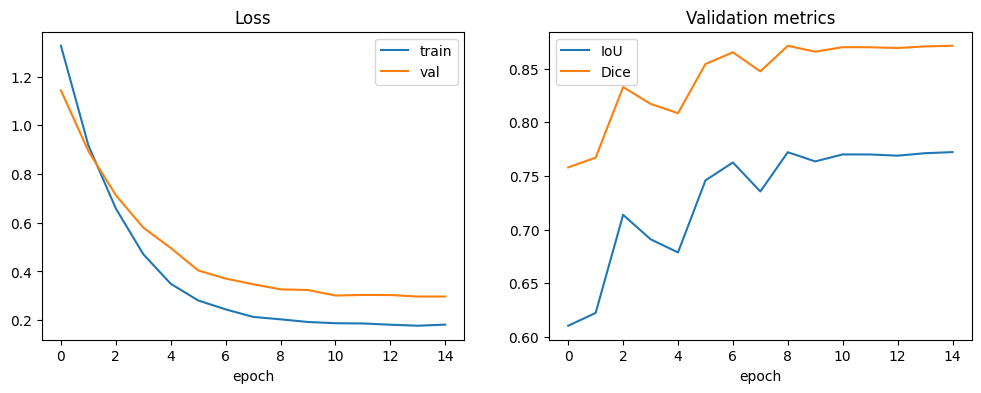


TEST (efficientnet-b0) IoU 0.748 | Dice 0.856 | Precision 0.923 | Recall 0.798
Params 6.3M | checkpoint 25 MB


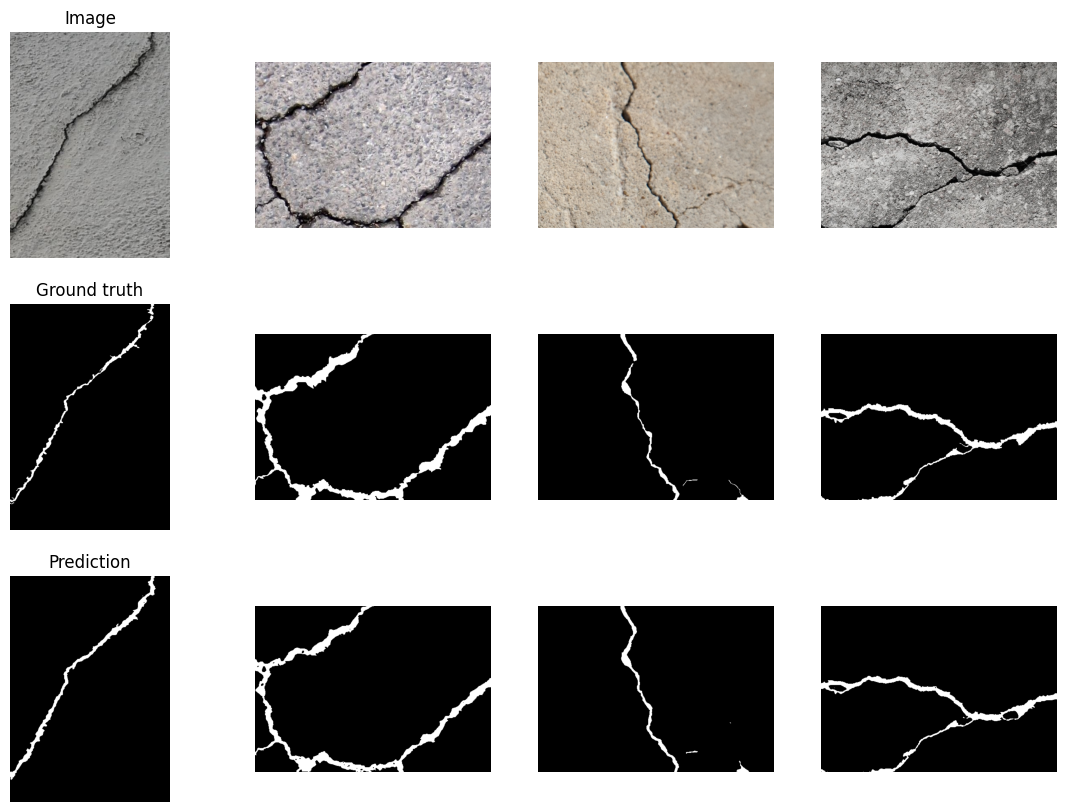

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history["val_iou"], label="IoU"); ax[1].plot(history["val_dice"], label="Dice")
ax[1].set_title("Validation metrics"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.show()

model.load_state_dict(torch.load(ckpt, map_location=device))
t = evaluate(test_dl)
print(f"\nTEST ({BACKBONE}) IoU {t['iou']:.3f} | Dice {t['dice']:.3f} | Precision {t['precision']:.3f} | Recall {t['recall']:.3f}")
print(f"Params {n_params:.1f}M | checkpoint {os.path.getsize(ckpt)/1e6:.0f} MB")

model.eval()
fig, ax = plt.subplots(3, 4, figsize=(14, 10))
for k in range(4):
    x, y = test_dl.dataset[k * 20]
    with torch.no_grad():
        pred = torch.sigmoid(model(x.unsqueeze(0).to(device)).float())[0, 0].cpu().numpy() > 0.5
    ax[0, k].imshow((x.permute(1, 2, 0).numpy() * STD + MEAN).clip(0, 1))
    ax[1, k].imshow(y[0], cmap="gray"); ax[2, k].imshow(pred, cmap="gray")
    for r in range(3): ax[r, k].axis("off")
ax[0, 0].set_title("Image"); ax[1, 0].set_title("Ground truth"); ax[2, 0].set_title("Prediction")
plt.show()

In [ ]:
from google.colab import files

THRESH = 0.5      # decision threshold
MAX_SIDE = 1024   # phone photos are huge; this downscales for a quick test only
                  # (downscaling erases hairline cracks, so don't use it for real measurement)

model_path = f"{SAVE_DIR}/unet_{BACKBONE}_best.pth"
if not os.path.exists(model_path):
    raise FileNotFoundError(
        f"Model file not found at {model_path}. "
        "Please ensure the training cell (cell DSMwScZjp7Hl) has been run "
        "successfully and the file exists in your Google Drive."
    )
model = smp.Unet(BACKBONE, encoder_weights=None, in_channels=3, classes=1).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

def segment(img_rgb):
    h, w = img_rgb.shape[:2]
    s = min(1.0, MAX_SIDE / max(h, w))
    if s < 1:
        img_rgb = cv2.resize(img_rgb, (int(w * s), int(h * s)), interpolation=cv2.INTER_AREA)
    h2, w2 = img_rgb.shape[:2]
    x = (img_rgb / 255.0 - np.array(MEAN)) / np.array(STD)
    x = np.pad(x, ((0, (-h2) % 32), (0, (-w2) % 32), (0, 0)))
    x = torch.from_numpy(x.transpose(2, 0, 1)).float().unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(x).float())[0, 0].cpu().numpy()
    return img_rgb, prob[:h2, :w2]

for name in files.upload():
    img, prob = segment(cv2.cvtColor(cv2.imread(name), cv2.COLOR_BGR2RGB))
    mask = prob > THRESH
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(img); ax[0].set_title("Image")
    ax[1].imshow(mask, cmap="gray"); ax[1].set_title(f"Mask (crack pixels: {mask.mean()*100:.2f}%)")
    ax[2].imshow(img); ax[2].imshow(np.ma.masked_where(~mask, mask), cmap="Reds", alpha=0.6); ax[2].set_title("Overlay")
    for a in ax: a.axis("off")
    plt.show()

In [25]:
print("Drive mounted:", os.path.exists("/content/drive/MyDrive"))
print("SAVE_DIR exists:", os.path.exists(SAVE_DIR))
if os.path.exists(SAVE_DIR):
    print("Contents:", os.listdir(SAVE_DIR))
!find /content -name "*.pth" 2>/dev/null
!find /content/drive/MyDrive -name "unet_*" 2>/dev/null

Drive mounted: True
SAVE_DIR exists: True
Contents: ['models', 'unet_efficientnet-b0_best.pth', 'history_efficientnet-b0.json']
/content/drive/MyDrive/TIP Files/41S2/CPE 029 (PD1)/PD1 FILES (1)/Software/unet_efficientnet-b0_best.pth
/content/drive/MyDrive/TIP Files/41S2/CPE 029 (PD1)/PD1 FILES (1)/Software/unet_efficientnet-b0_best.pth
